In [1]:
import pandas as pd

df = pd.read_csv("student-mat.csv", sep=";")

In [2]:
print(df.head())
print(df.columns)

  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        6   5   6   6  
1      5        3      3     1     1      3        4   5   5   6  
2      4        3      2     2     3      3       10   7   8  10  
3      3        2      2     1     1      5        2  15  14  15  
4      4        3      2     1     2      5        4   6  10  10  

[5 rows x 33 columns]
Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       '

In [3]:
df["At_Risk"] = (df["G3"] < 10).astype(int)

print(df["At_Risk"].value_counts())

At_Risk
0    265
1    130
Name: count, dtype: int64


In [4]:
X = df.drop(["G3", "At_Risk"], axis=1)

y = df["At_Risk"]

print(X.shape)
print(y.shape)

(395, 32)
(395,)


In [5]:
X = pd.get_dummies(X, drop_first=True)

print(X.shape)

(395, 41)


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(316, 41)
(79, 41)
(316,)
(79,)


In [7]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 1.0/101.7 MB 5.7 MB/s eta 0:00:18
   - -------------------------------------- 3.1/101.7 MB 8.3 MB/s eta 0:00:12
   -- ------------------------------------- 6.3/101.7 MB 10.8 MB/s eta 0:00:09
   --- ------------------------------------ 10.0/101.7 MB 12.7 MB/s eta 0:00:08
   ----- ---------------------------------- 13.4/101.7 MB 13.4 MB/s eta 0:00:07
   ------ --------------------------------- 17.3/101.7 MB 14.3 MB/s eta 0:00:06
   -------- ------------------------------- 21.0/101.7 MB 14.7 MB/s eta 0:00:06
   --------- ------------------------------ 24.4/101.7 MB 14.9 MB/s eta 0:00:06
   ---------- ----------------------------- 27.5/101.7 MB 14.9 MB/s eta 0:00:05
   ------------ --------------------------- 31.5/101.7 MB 15.3 MB/s eta 0:00:05
   ------------- -------------------------- 35.1/101.7 MB 15.5 

In [8]:
from xgboost import XGBClassifier

model = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [9]:
from sklearn.metrics import accuracy_score

pred = model.predict(X_test)

print(pred[:10])

[1 0 1 0 0 0 0 1 1 0]


In [10]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, pred)

print("Accuracy:", accuracy)

Accuracy: 0.8734177215189873


In [11]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(10))

              Feature  Importance
14                 G2    0.351199
31    guardian_mother    0.084334
25         Fjob_other    0.063968
18        famsize_LE3    0.044604
13                 G1    0.042684
11             health    0.037229
30  reason_reputation    0.026911
1                Medu    0.026312
2                Fedu    0.025802
33      schoolsup_yes    0.025435


In [12]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.92      0.88      0.90        52
           1       0.79      0.85      0.82        27

    accuracy                           0.87        79
   macro avg       0.86      0.87      0.86        79
weighted avg       0.88      0.87      0.87        79



In [13]:
!pip install shap


   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]



In [14]:
import shap

In [15]:
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

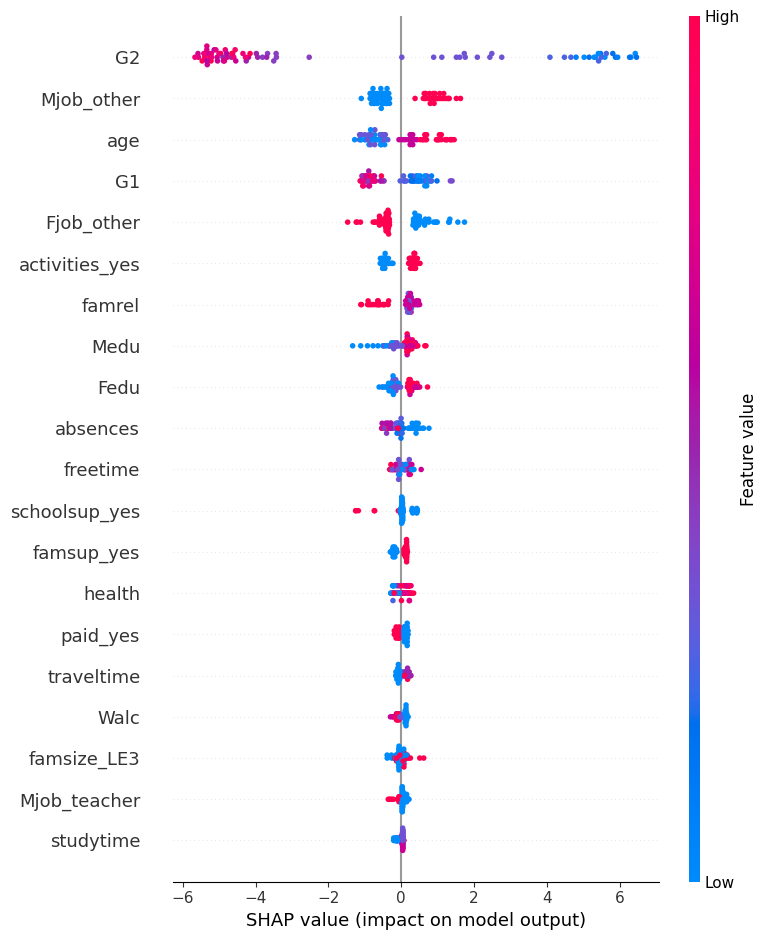

In [16]:
shap.summary_plot(shap_values, X_test)

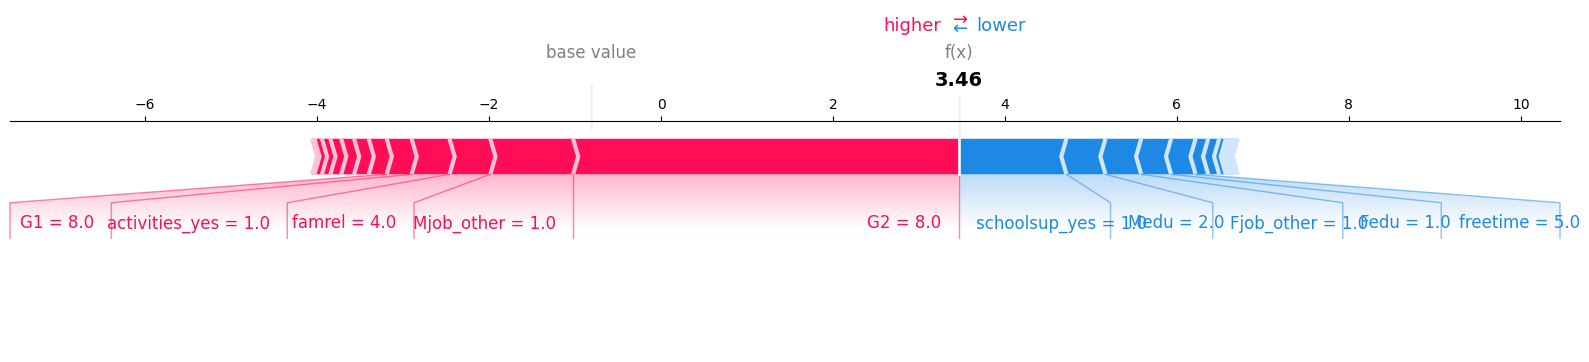

In [17]:
student_index = 0

shap.force_plot(
    explainer.expected_value,
    shap_values[student_index],
    X_test.iloc[student_index],
    matplotlib=True
)

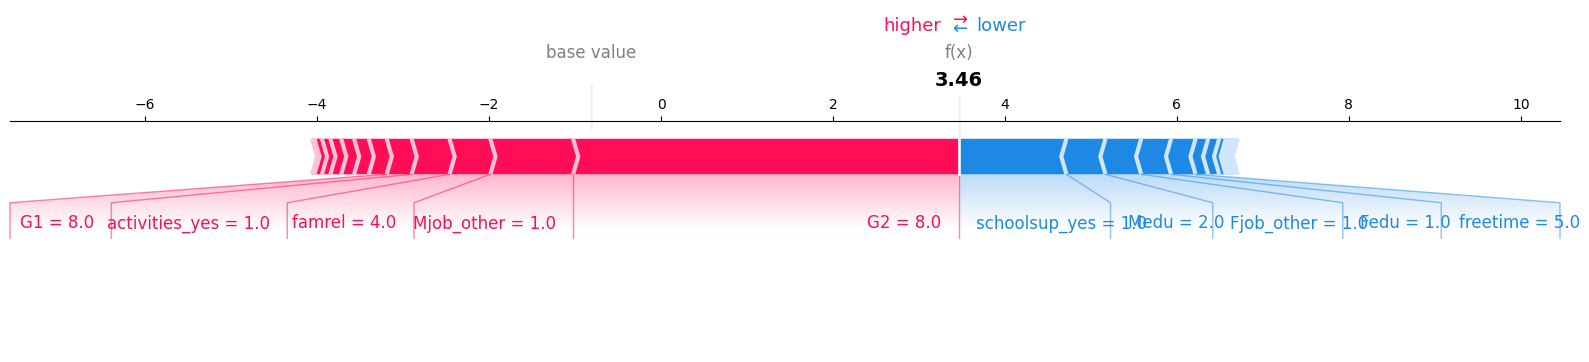

In [18]:
student_index = 0

shap.force_plot(
    explainer.expected_value,
    shap_values[student_index],
    X_test.iloc[student_index],
    matplotlib=True
)

In [19]:
print("Prediction:", pred[0])
print("Actual:", y_test.iloc[0])

Prediction: 1
Actual: 0


In [20]:
proba = model.predict_proba(X_test)

print(proba[0])

[0.03043246 0.96956754]


In [21]:
X = df.drop(["G1", "G2", "G3", "At_Risk"], axis=1)

In [22]:
X = df.drop(["G1", "G2", "G3", "At_Risk"], axis=1)

X = pd.get_dummies(X, drop_first=True)

print(X.shape)

(395, 39)


In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [24]:
from xgboost import XGBClassifier

model = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [25]:
from sklearn.metrics import accuracy_score

pred = model.predict(X_test)

accuracy = accuracy_score(y_test, pred)

print("Accuracy:", accuracy)

Accuracy: 0.7215189873417721


In [26]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(10))

           Feature  Importance
5         failures    0.101118
30  guardian_other    0.082366
37    internet_yes    0.047479
31   schoolsup_yes    0.043786
36      higher_yes    0.040474
20   Mjob_services    0.039211
18     Mjob_health    0.038388
35     nursery_yes    0.029506
4        studytime    0.029265
2             Fedu    0.029231


In [27]:
proba = model.predict_proba(X_test)

risk_scores = proba[:,1]

print(risk_scores[:10])

[0.870553   0.4638334  0.747854   0.02237986 0.6685795  0.5330227
 0.01763543 0.13457958 0.84187675 0.03861529]


In [28]:
def risk_level(score):
    if score >= 0.8:
        return "High Risk"
    elif score >= 0.5:
        return "Medium Risk"
    else:
        return "Low Risk"

In [29]:
for score in risk_scores[:5]:
    print(score, risk_level(score))

0.870553 High Risk
0.4638334 Low Risk
0.747854 Medium Risk
0.022379862 Low Risk
0.6685795 Medium Risk


In [30]:
def get_interventions(student):

    interventions = []

    if student["failures"] > 0:
        interventions.append(
            "Assign remedial academic support"
        )

    if student["studytime"] < 2:
        interventions.append(
            "Recommend structured study schedule"
        )

    if student["absences"] > 10:
        interventions.append(
            "Monitor attendance closely"
        )

    return interventions

In [31]:
student = X_test.iloc[0]

print("Risk Score:", risk_scores[0])
print("Risk Level:", risk_level(risk_scores[0]))

print("\nRecommended Actions:")

for item in get_interventions(student):
    print("-", item)

Risk Score: 0.870553
Risk Level: High Risk

Recommended Actions:
- Assign remedial academic support
- Recommend structured study schedule


In [32]:
student_original = df.iloc[X_test.index[0]]

print(student_original[[
    "failures",
    "studytime",
    "absences",
    "health"
]])

failures     3
studytime    1
absences     2
health       3
Name: 78, dtype: object


In [33]:
def get_interventions(student):

    interventions = []

    if student["failures"] > 0:
        interventions.append(
            "Enroll student in remedial support program"
        )

    if student["studytime"] < 2:
        interventions.append(
            "Create a structured weekly study plan"
        )

    if student["absences"] > 10:
        interventions.append(
            "Monitor attendance and contact guardian"
        )

    if student["health"] <= 2:
        interventions.append(
            "Recommend counselling and wellbeing support"
        )

    if len(interventions) == 0:
        interventions.append(
            "Continue regular monitoring"
        )

    return interventions

In [34]:
student = df.iloc[X_test.index[0]]

print("="*50)
print("FAILSAFE STUDENT REPORT")
print("="*50)

print(f"Risk Score: {risk_scores[0]:.2%}")
print(f"Risk Level: {risk_level(risk_scores[0])}")

print("\nInterventions:")

for item in get_interventions(student):
    print(f"• {item}")

FAILSAFE STUDENT REPORT
Risk Score: 87.06%
Risk Level: High Risk

Interventions:
• Enroll student in remedial support program
• Create a structured weekly study plan


In [35]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.


In [39]:
print(X.columns)

Index(['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel',
       'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'school_MS',
       'sex_M', 'address_U', 'famsize_LE3', 'Pstatus_T', 'Mjob_health',
       'Mjob_other', 'Mjob_services', 'Mjob_teacher', 'Fjob_health',
       'Fjob_other', 'Fjob_services', 'Fjob_teacher', 'reason_home',
       'reason_other', 'reason_reputation', 'guardian_mother',
       'guardian_other', 'schoolsup_yes', 'famsup_yes', 'paid_yes',
       'activities_yes', 'nursery_yes', 'higher_yes', 'internet_yes',
       'romantic_yes'],
      dtype='object')


In [37]:
import joblib

joblib.dump(model, "failsafe_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [38]:
import os
print(os.getcwd())

C:\Users\User\cc project


In [40]:
print(X.head(1).T)

                       0
age                   18
Medu                   4
Fedu                   4
traveltime             2
studytime              2
failures               0
famrel                 4
freetime               3
goout                  4
Dalc                   1
Walc                   1
health                 3
absences               6
school_MS          False
sex_M              False
address_U           True
famsize_LE3        False
Pstatus_T          False
Mjob_health        False
Mjob_other         False
Mjob_services      False
Mjob_teacher       False
Fjob_health        False
Fjob_other         False
Fjob_services      False
Fjob_teacher        True
reason_home        False
reason_other       False
reason_reputation  False
guardian_mother     True
guardian_other     False
schoolsup_yes       True
famsup_yes         False
paid_yes           False
activities_yes     False
nursery_yes         True
higher_yes          True
internet_yes       False
romantic_yes       False


In [41]:
print(len(X.columns))
print(list(X.columns))

39
['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'school_MS', 'sex_M', 'address_U', 'famsize_LE3', 'Pstatus_T', 'Mjob_health', 'Mjob_other', 'Mjob_services', 'Mjob_teacher', 'Fjob_health', 'Fjob_other', 'Fjob_services', 'Fjob_teacher', 'reason_home', 'reason_other', 'reason_reputation', 'guardian_mother', 'guardian_other', 'schoolsup_yes', 'famsup_yes', 'paid_yes', 'activities_yes', 'nursery_yes', 'higher_yes', 'internet_yes', 'romantic_yes']


In [42]:
import joblib

loaded_model = joblib.load("failsafe_model.pkl")

print(type(loaded_model))

<class 'xgboost.sklearn.XGBClassifier'>


In [43]:
print(loaded_model)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)
